# Product Analysis

**Context:** User-level analysis showed cart and wishlist adds carry no predictive value for purchase; only session frequency differs between buyers and non-buyers. This notebook examines the same gap at the product level.

**Data approach:** Behavioral rates (view→cart→wishlist→purchase) use the `events` table only. Revenue figures use `order_items` as source of truth. No cross-source conversion rates are computed.

In [13]:
from src.db import run_sql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [14]:
df = run_sql("../sql/product_mart_v2.sql")

viewed = df[df['views_count'] > 0].copy()
viewed['v2c'] = viewed['cart_adds']       / viewed['views_count']
viewed['v2w'] = viewed['wishlist_adds']   / viewed['views_count']
viewed['v2p'] = viewed['purchase_events'] / viewed['views_count']

print(f"Total products:                    {len(df):,}")
print(f"Categories:                        {df['category'].nunique()}")
print(f"Products with views:               {(df['views_count'] > 0).sum():,}")
print(f"Products with purchase_events > 0: {(df['purchase_events'] > 0).sum():,}")
print(f"Products with 0 purchase_events:   {(df['purchase_events'] == 0).sum():,}")
print(f"\nBehavioral rates (events only):")
print(f"  Avg view-to-cart rate:     {viewed['v2c'].mean()*100:.1f}%")
print(f"  Avg view-to-wishlist rate: {viewed['v2w'].mean()*100:.1f}%")
print(f"  Avg view-to-purchase rate: {viewed['v2p'].mean()*100:.1f}%")

Total products:                    2,000
Categories:                        10
Products with views:               2,000
Products with purchase_events > 0: 1,725
Products with 0 purchase_events:   275

Behavioral rates (events only):
  Avg view-to-cart rate:     22.3%
  Avg view-to-wishlist rate: 14.7%
  Avg view-to-purchase rate: 7.5%


In [15]:
df['brand'].unique()

array(['Astra', 'NeoTech', 'Acme', 'Nimbus', 'Zenith', 'Everest',
       'Harbor', 'Orion', 'GreenLeaf', 'Solace', 'Willow', 'Pulse'],
      dtype=object)

---
## Block A: Behavioral Analysis (Events Only)

### A1. Product Funnel by Category

                avg_views  avg_cart  avg_wishlist  avg_purchases
category                                                        
Pet Supplies        28.30      6.16          4.12           1.97
Clothing            28.28      5.96          3.74           1.91
Electronics         28.22      5.96          3.84           2.01
Home & Kitchen      28.21      5.71          3.93           2.00
Sports              28.13      5.92          3.81           2.10
Beauty              27.91      6.01          4.01           1.96
Groceries           27.89      6.16          4.20           2.11
Automotive          27.83      6.12          3.91           2.01
Books               27.63      6.34          4.29           1.96
Toys                27.63      5.86          3.90           2.01


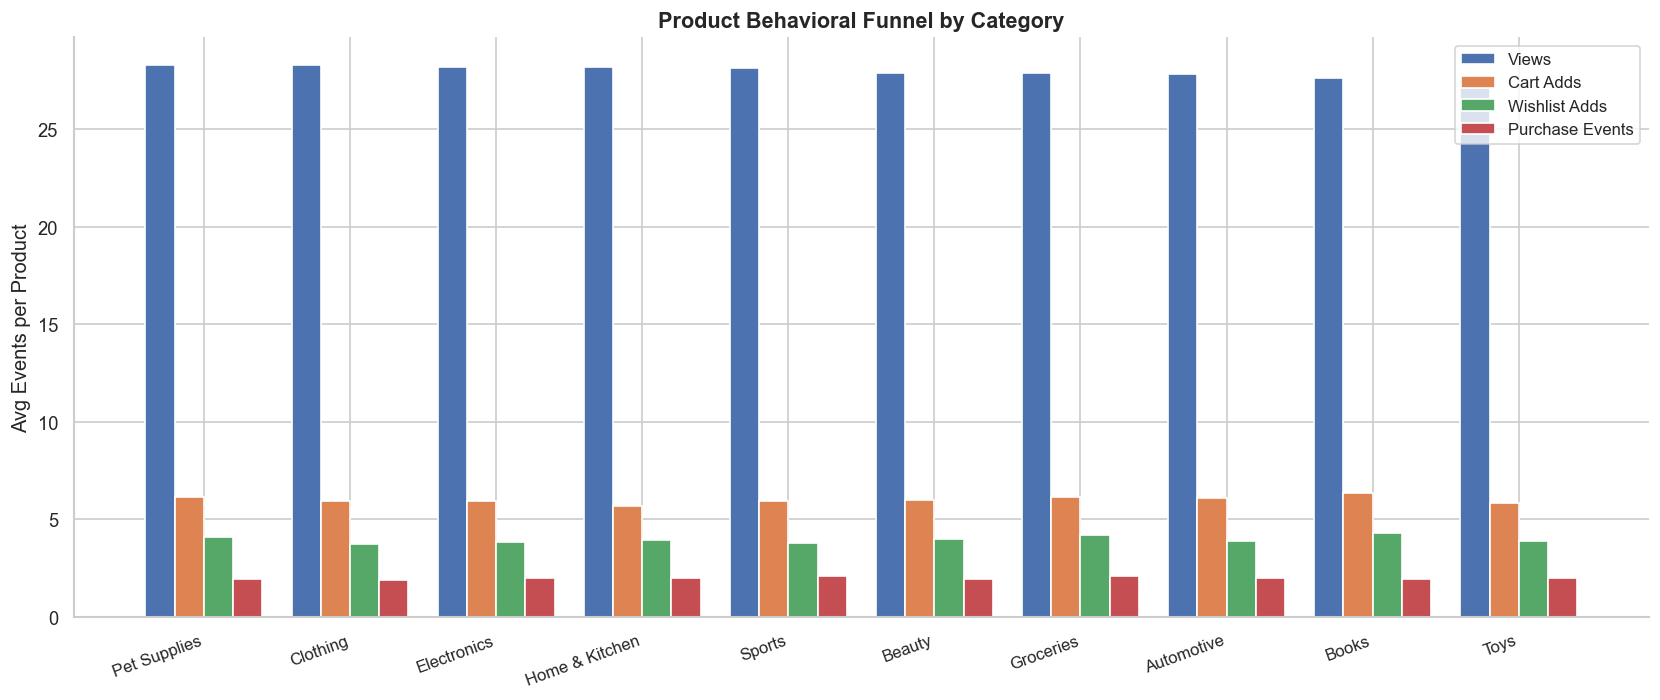

In [16]:
cat_funnel = df.groupby('category').agg(
    avg_views    =('views_count',     'mean'),
    avg_cart     =('cart_adds',       'mean'),
    avg_wishlist =('wishlist_adds',   'mean'),
    avg_purchases=('purchase_events', 'mean')
).round(2).sort_values('avg_views', ascending=False)

print(cat_funnel)

x, w = range(len(cat_funnel)), 0.2
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i-w*1.5 for i in x], cat_funnel['avg_views'],     w, label='Views',           color='#4C72B0', edgecolor='white')
ax.bar([i-w*0.5 for i in x], cat_funnel['avg_cart'],      w, label='Cart Adds',       color='#DD8452', edgecolor='white')
ax.bar([i+w*0.5 for i in x], cat_funnel['avg_wishlist'],  w, label='Wishlist Adds',   color='#55A868', edgecolor='white')
ax.bar([i+w*1.5 for i in x], cat_funnel['avg_purchases'], w, label='Purchase Events', color='#C44E52', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(cat_funnel.index, rotation=20, ha='right', fontsize=10)
ax.set_title("Product Behavioral Funnel by Category", fontsize=13, fontweight='bold')
ax.set_ylabel("Avg Events per Product")
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

The funnel pattern is nearly identical across all 10 categories: ~28 views → ~6 cart adds → ~4 wishlist adds → ~2 purchase events per product. No category stands out as significantly better or worse. This confirms the conversion gap is structural — it is not driven by any specific category performing differently in behavioral engagement.

### A2. View-to-Cart and View-to-Wishlist Rate by Category

                  v2c    v2w   v2p
category                          
Home & Kitchen  21.23  14.44  7.37
Sports          21.62  13.96  7.71
Electronics     21.87  14.13  7.44
Clothing        22.15  13.77  7.09
Toys            22.19  14.83  7.57
Beauty          22.22  14.77  7.23
Automotive      22.66  14.46  7.57
Pet Supplies    22.66  15.23  7.32
Groceries       22.72  15.35  7.88
Books           23.84  15.96  7.41


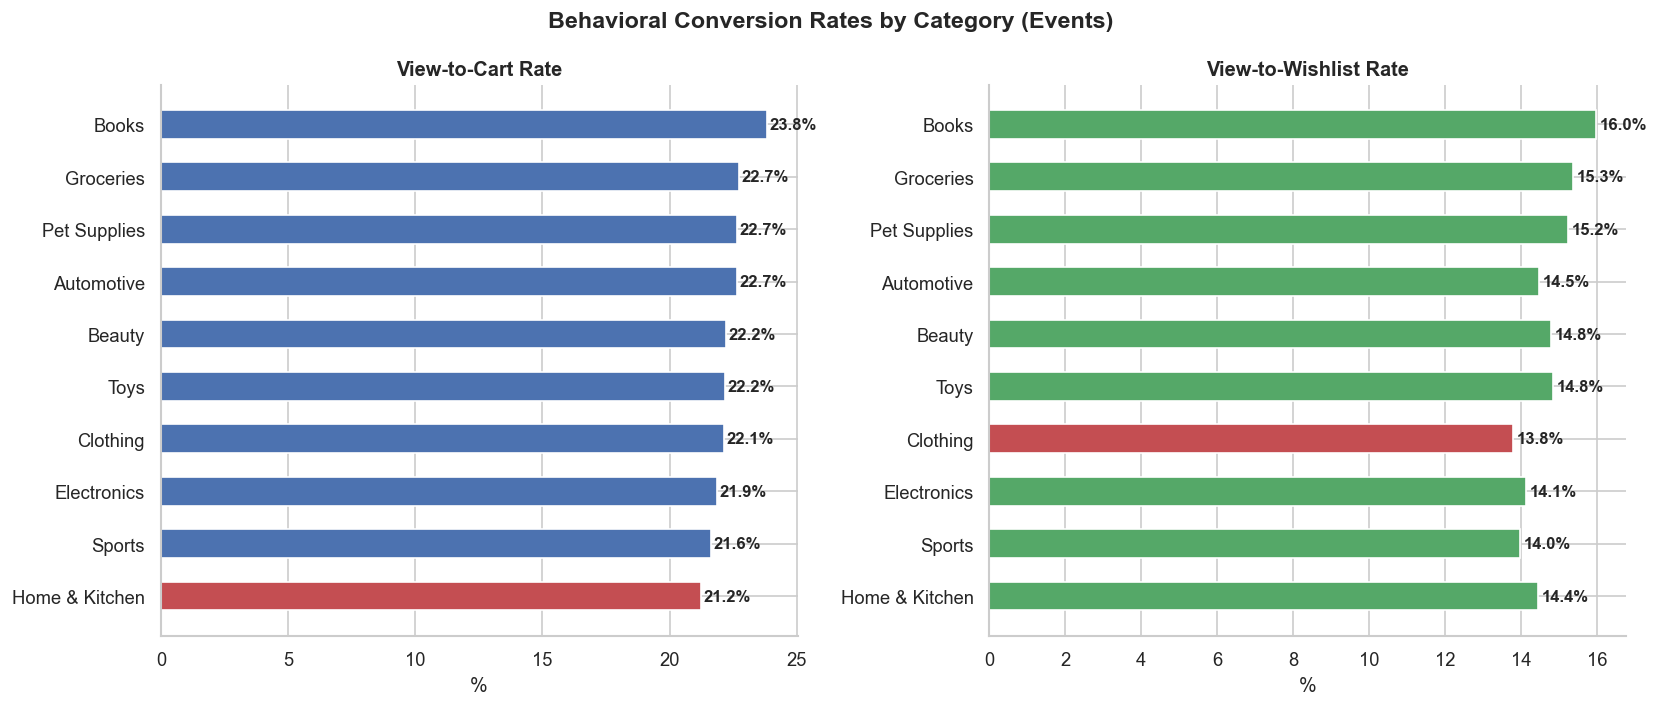

In [17]:
cat_rates = viewed.groupby('category').agg(
    v2c=('v2c','mean'), v2w=('v2w','mean'), v2p=('v2p','mean')
).mul(100).round(2).sort_values('v2c', ascending=True)

print(cat_rates)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_c = ['#C44E52' if v == cat_rates['v2c'].min() else '#4C72B0' for v in cat_rates['v2c']]
bars = axes[0].barh(cat_rates.index, cat_rates['v2c'], color=colors_c, edgecolor='white', height=0.55)
for bar, val in zip(bars, cat_rates['v2c']):
    axes[0].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va='center', fontsize=10, fontweight='bold')
axes[0].set_title("View-to-Cart Rate", fontsize=12, fontweight='bold')
axes[0].set_xlabel("%")
sns.despine(ax=axes[0])

colors_w = ['#C44E52' if v == cat_rates['v2w'].min() else '#55A868' for v in cat_rates['v2w']]
bars2 = axes[1].barh(cat_rates.index, cat_rates['v2w'], color=colors_w, edgecolor='white', height=0.55)
for bar, val in zip(bars2, cat_rates['v2w']):
    axes[1].text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va='center', fontsize=10, fontweight='bold')
axes[1].set_title("View-to-Wishlist Rate", fontsize=12, fontweight='bold')
axes[1].set_xlabel("%")
sns.despine(ax=axes[1])

fig.suptitle("Behavioral Conversion Rates by Category (Events)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

View-to-cart ranges from 21.2% (Home & Kitchen) to 23.8% (Books) a spread of only 2.6 percentage points. View-to-wishlist ranges from 13.8% (Clothing) to 16.0% (Books). Books consistently leads both metrics; Clothing and Home & Kitchen are at the bottom. The narrow spread confirms no single category has a dramatically different conversion problem at the cart/wishlist stage.

### A3. View-to-Purchase Rate by Category

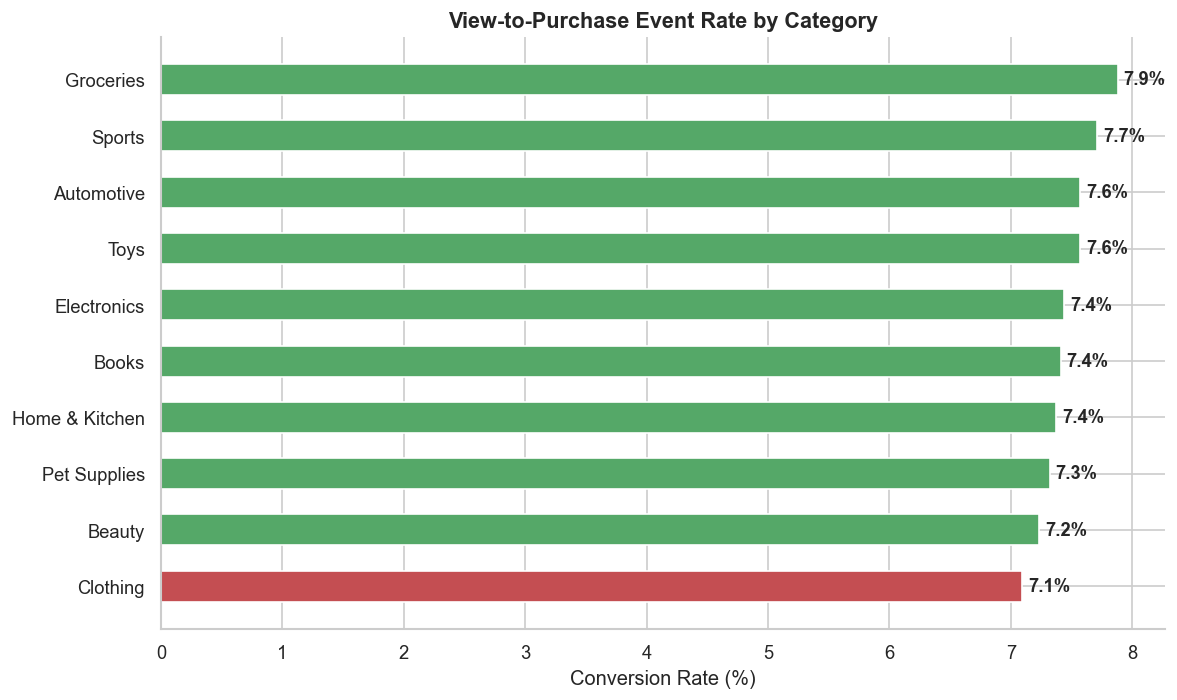

In [18]:
cat_v2p = cat_rates.sort_values('v2p', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors2 = ['#C44E52' if v == cat_v2p['v2p'].min() else '#55A868' for v in cat_v2p['v2p']]
bars = ax.barh(cat_v2p.index, cat_v2p['v2p'], color=colors2, edgecolor='white', height=0.55)
for bar, val in zip(bars, cat_v2p['v2p']):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=11, fontweight='bold')
ax.set_title("View-to-Purchase Event Rate by Category", fontsize=13, fontweight='bold')
ax.set_xlabel("Conversion Rate (%)")
sns.despine()
plt.tight_layout()
plt.show()

View-to-purchase rates are similar across categories (7.1%–7.9%). Clothing has the lowest final conversion, meaning users often add items to cart but do not buy. Groceries has the highest conversion, likely due to more intentional shopping behavior.

---
## Block B: Revenue Analysis (Orders Only)

### B1. Revenue by Category

Revenue by category:
  Electronics          $   4,961,737  (41.6%)
  Automotive           $   2,501,361  (21.0%)
  Home & Kitchen       $   1,132,697  (9.5%)
  Sports               $     952,403  (8.0%)
  Clothing             $     710,954  (6.0%)
  Beauty               $     555,775  (4.7%)
  Toys                 $     385,483  (3.2%)
  Pet Supplies         $     354,036  (3.0%)
  Books                $     274,826  (2.3%)
  Groceries            $      89,398  (0.8%)


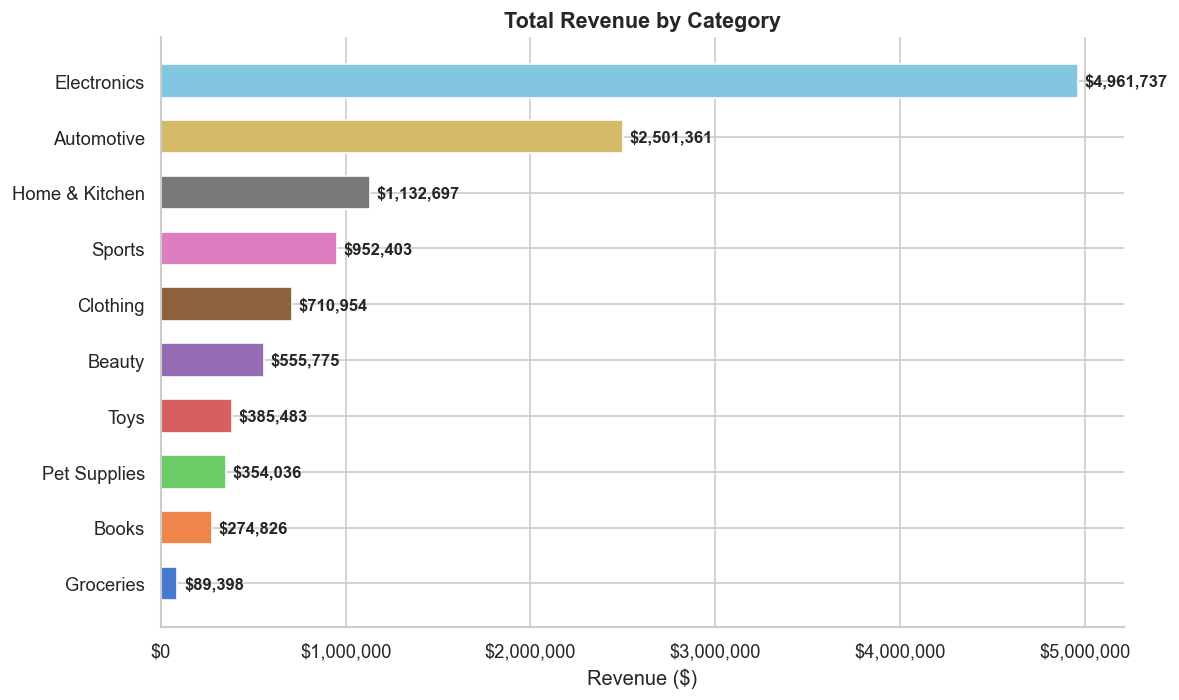

In [19]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=True)
total_rev = cat_rev.sum()

print("Revenue by category:")
for cat, rev in cat_rev.sort_values(ascending=False).items():
    print(f"  {cat:<20} ${rev:>12,.0f}  ({rev/total_rev*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_rev.index, cat_rev.values,
               color=sns.color_palette('muted', len(cat_rev)), edgecolor='white', height=0.6)
for bar, val in zip(bars, cat_rev.values):
    ax.text(bar.get_width()+total_rev*0.003, bar.get_y()+bar.get_height()/2,
            f"${val:,.0f}", va='center', fontsize=10, fontweight='bold')
ax.set_title("Total Revenue by Category", fontsize=13, fontweight='bold')
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

Electronics generates the most revenue $4.96M (41.6% of total). Together with Automotive, it makes up 62.6% of all revenue, while Groceries contributes only 0.8%. This shows that revenue differences come mainly from product prices, not from user engagement.


### B2. Top 15 Products by Revenue

   product_name    category   price  units_sold  revenue
  Willow Result Electronics 2035.42          36 73275.12
     Astra Pull Electronics 2338.13          28 65467.64
 Willow Special Electronics 1772.36          35 62032.60
    Orion Group Electronics 2337.85          26 60784.10
   Zenith Phone Electronics 2169.98          26 56419.48
Willow Hospital  Automotive 1340.76          42 56311.92
  Nimbus Family Electronics 1700.35          32 54411.20
   Zenith Their Electronics 1599.98          34 54399.32
     Orion Face Electronics 1352.63          40 54105.20
        Acme Of Electronics 1407.61          38 53489.18
    Pulse Treat Electronics 1236.42          43 53166.06
    Harbor Onto Electronics 1226.78          41 50297.98
   Orion Number Electronics 1338.53          37 49525.61
    Willow Note Electronics 1535.55          32 49137.60
GreenLeaf Later Electronics 1413.41          34 48055.94


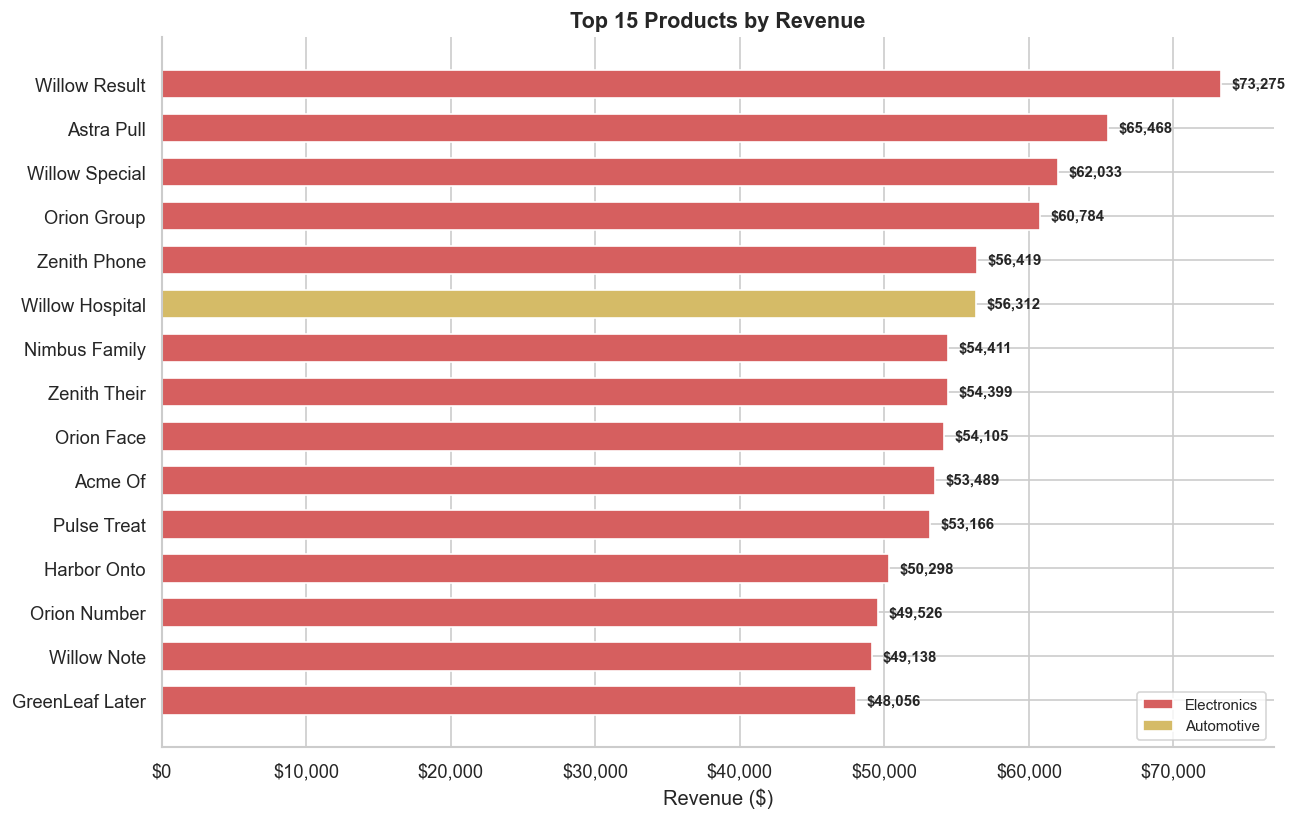

In [20]:
top15 = df.nlargest(15, 'revenue')[['product_name','category','price','units_sold','revenue']]
print(top15.to_string(index=False))

top15_sorted = top15.sort_values('revenue', ascending=True)
cat_colors   = {c: col for c, col in zip(df['category'].unique(), sns.color_palette('muted', df['category'].nunique()))}
colors_b2    = [cat_colors[c] for c in top15_sorted['category']]

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15_sorted['product_name'], top15_sorted['revenue'], color=colors_b2, edgecolor='white', height=0.65)
for bar, val in zip(bars, top15_sorted['revenue']):
    ax.text(bar.get_width()+top15_sorted['revenue'].max()*0.01,
            bar.get_y()+bar.get_height()/2,
            f"${val:,.0f}", va='center', fontsize=9, fontweight='bold')
legend_els = [Patch(facecolor=cat_colors[c], label=c) for c in top15_sorted['category'].unique()]
ax.legend(handles=legend_els, fontsize=9, loc='lower right')
ax.set_title("Top 15 Products by Revenue", fontsize=13, fontweight='bold')
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()

14 of the top 15 products by revenue are from Electronics, with only one Automotive product in the list. The top product generated $73k revenue from just 36 sales because of its high price ($2,035). This shows that Electronics dominates revenue mainly due to expensive products, not higher sales volume.

### B3. Price Tier vs Sales Volume

            avg_units  avg_rev  count
price_tier                           
Budget           30.5    580.8    500
Mid              31.0   1804.4    500
Premium          30.3   4027.9    500
Luxury           29.9  17424.2    500


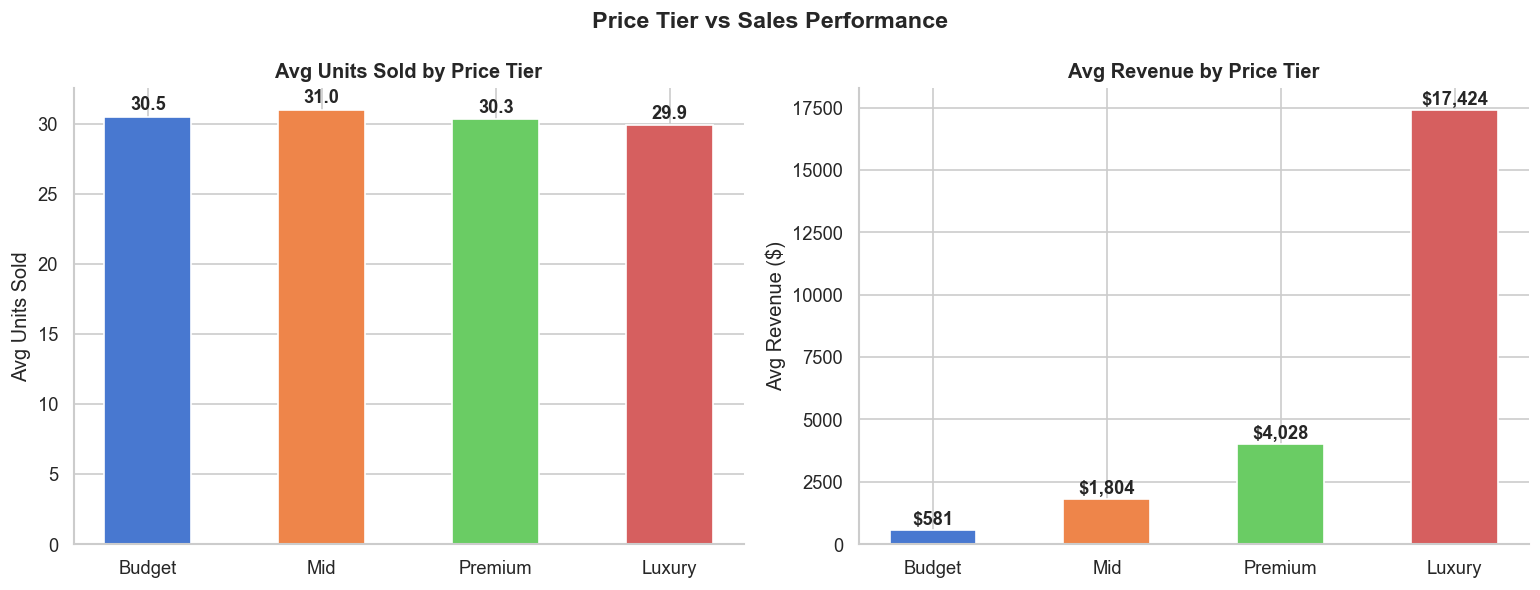

In [21]:
sold = df[df['units_sold'] > 0].copy()
sold['price_tier'] = pd.qcut(sold['price'], q=4, labels=['Budget','Mid','Premium','Luxury'])

tier_agg = sold.groupby('price_tier', observed=True).agg(
    avg_units=('units_sold','mean'), avg_rev=('revenue','mean'), count=('product_id','count')
).round(1)
print(tier_agg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors_t = sns.color_palette('muted', 4)

bars1 = axes[0].bar(tier_agg.index.astype(str), tier_agg['avg_units'], color=colors_t, width=0.5, edgecolor='white')
for bar, val in zip(bars1, tier_agg['avg_units']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"{val:.1f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title("Avg Units Sold by Price Tier", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Avg Units Sold")
sns.despine(ax=axes[0])

bars2 = axes[1].bar(tier_agg.index.astype(str), tier_agg['avg_rev'], color=colors_t, width=0.5, edgecolor='white')
for bar, val in zip(bars2, tier_agg['avg_rev']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f"${val:,.0f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title("Avg Revenue by Price Tier", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Avg Revenue ($)")
sns.despine(ax=axes[1])

fig.suptitle("Price Tier vs Sales Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Units sold stay almost the same across all price tiers, from Budget to Luxury. However, revenue per product increases sharply with price — Luxury products generate around 30x more revenue than Budget ones. This suggests that higher prices do not reduce demand in this dataset.

### B4. Product Rating vs Revenue

            avg_revenue  avg_units_sold  count
rating_bin                                    
Low (≤3)         5430.7            30.9    444
Good (3–4)       6505.8            30.4    838
High (4–5)       5648.4            30.1    718


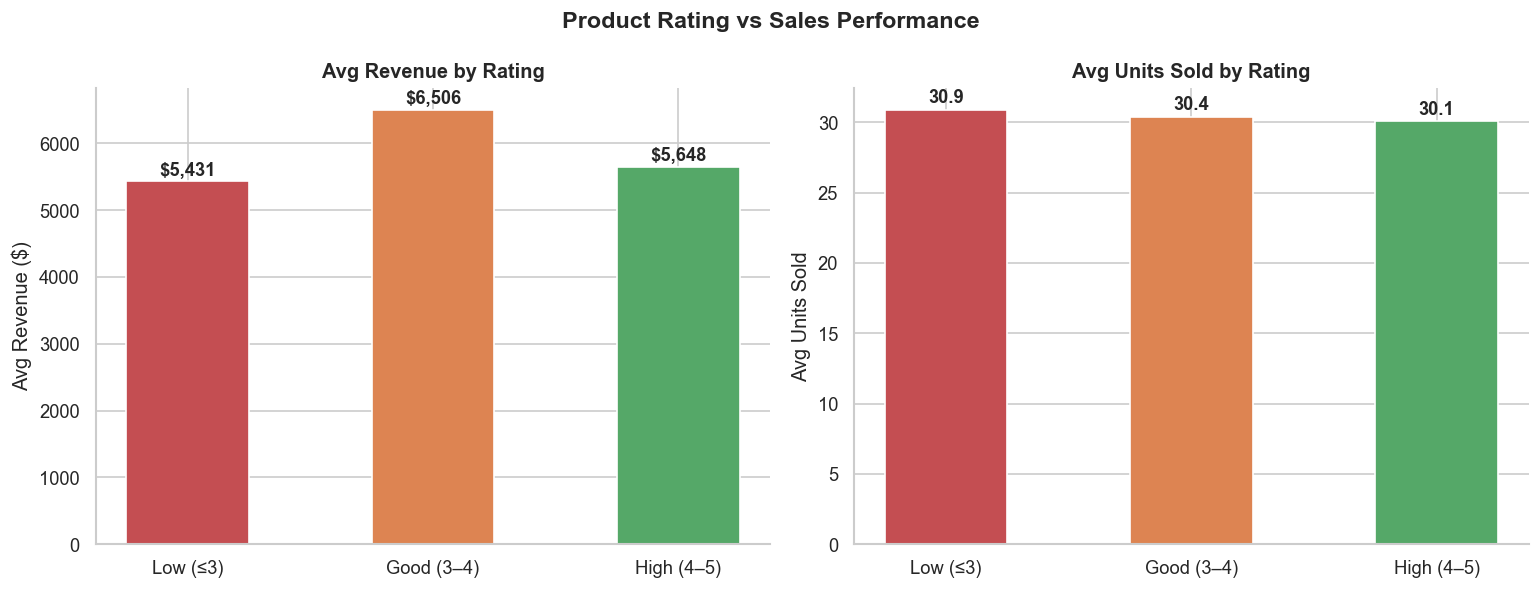

In [22]:
rated = df[df['product_rating'].notna() & (df['orders_count'] > 0)].copy()
rated['rating_bin'] = pd.cut(rated['product_rating'], bins=[0,3,4,5], labels=['Low (≤3)','Good (3–4)','High (4–5)'])

rat_agg = rated.groupby('rating_bin', observed=True).agg(
    avg_revenue   =('revenue',   'mean'),
    avg_units_sold=('units_sold','mean'),
    count         =('product_id','count')
).round(1)
print(rat_agg)

colors_r = ['#C44E52','#DD8452','#55A868']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(rat_agg.index.astype(str), rat_agg['avg_revenue'], color=colors_r, width=0.5, edgecolor='white')
for bar, val in zip(bars1, rat_agg['avg_revenue']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f"${val:,.0f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title("Avg Revenue by Rating", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Avg Revenue ($)")
sns.despine(ax=axes[0])

bars2 = axes[1].bar(rat_agg.index.astype(str), rat_agg['avg_units_sold'], color=colors_r, width=0.5, edgecolor='white')
for bar, val in zip(bars2, rat_agg['avg_units_sold']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f"{val:.1f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title("Avg Units Sold by Rating", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Avg Units Sold")
sns.despine(ax=axes[1])

fig.suptitle("Product Rating vs Sales Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Product rating has little impact on sales or revenue. Products with low, medium, and high ratings sell almost the same number of units, while revenue differences are small and inconsistent. This suggests that price and product category influence revenue much more than ratings.

### B5. Brand Revenue by Category

Top 2 categories per brand (% of brand revenue):
  Willow       Electronics          47.4%  |  Automotive           28.0%
  Orion        Electronics          45.4%  |  Automotive           18.9%
  Nimbus       Electronics          36.1%  |  Automotive           23.0%
  Acme         Electronics          54.1%  |  Automotive           15.5%
  Astra        Electronics          42.8%  |  Automotive           27.5%
  Zenith       Electronics          39.5%  |  Automotive           16.1%
  GreenLeaf    Electronics          45.7%  |  Automotive           15.5%
  Harbor       Electronics          33.0%  |  Automotive           20.8%
  Solace       Electronics          34.4%  |  Automotive           24.7%
  Pulse        Electronics          52.1%  |  Automotive           20.3%
  Everest      Electronics          24.8%  |  Automotive           24.0%
  NeoTech      Electronics          37.7%  |  Automotive           14.6%


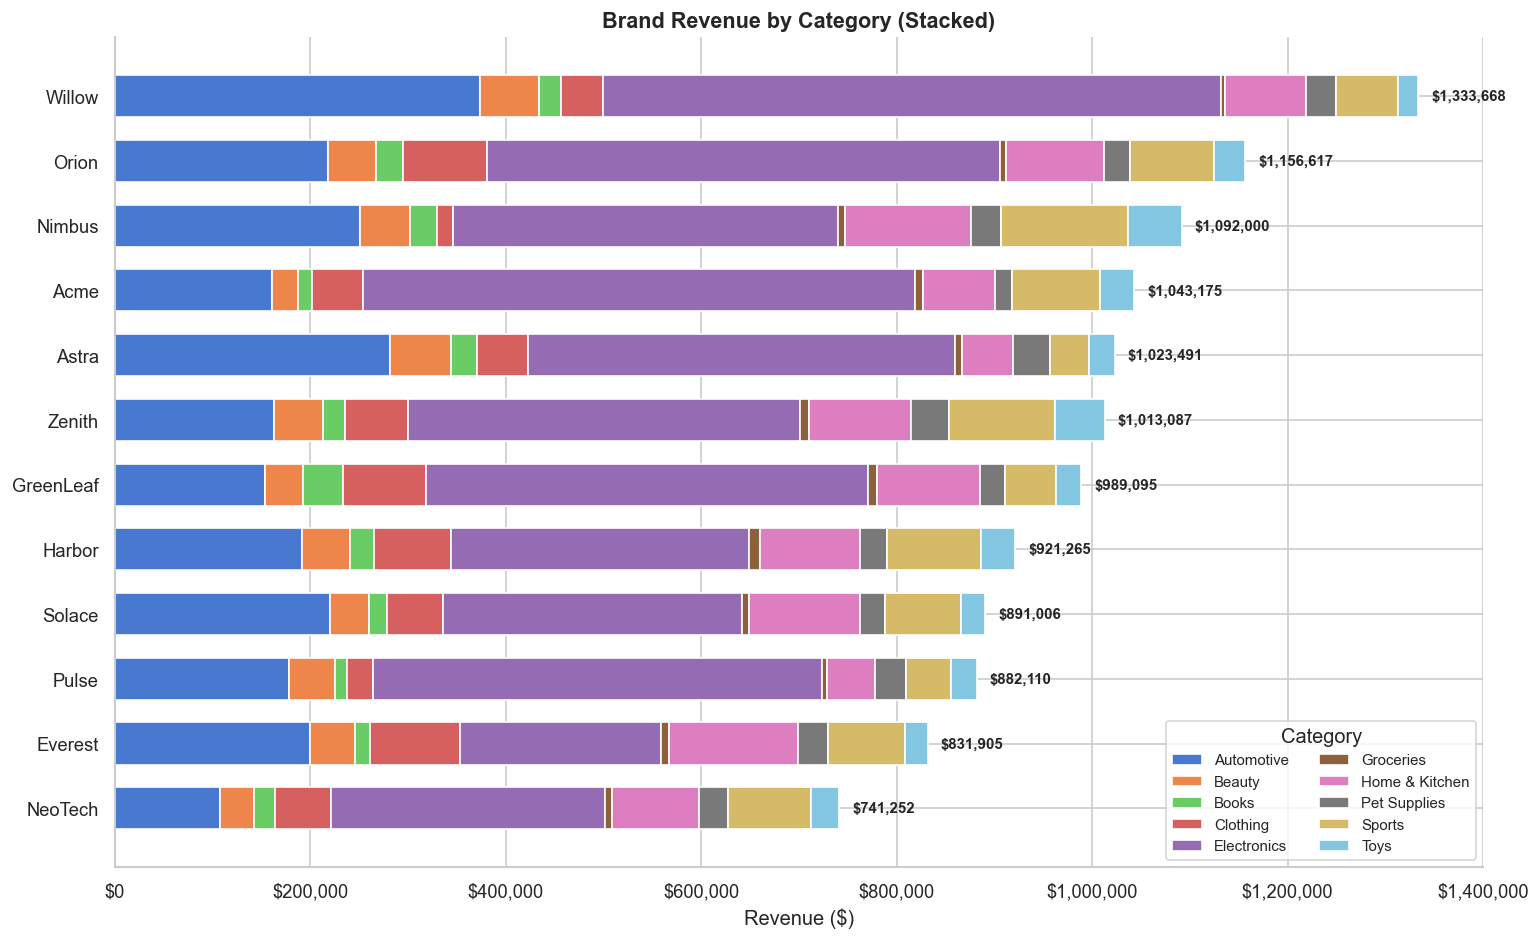

In [23]:
brand_cat = df.groupby(['brand','category'])['revenue'].sum().unstack(fill_value=0)
brand_totals = brand_cat.sum(axis=1).sort_values(ascending=True)
brand_cat_sorted = brand_cat.loc[brand_totals.index]

print("Top 2 categories per brand (% of brand revenue):")
for brand in brand_totals.sort_values(ascending=False).index:
    top = brand_cat.loc[brand].sort_values(ascending=False)
    print(f"  {brand:<12} {top.index[0]:<20} {top.iloc[0]/brand_totals[brand]*100:.1f}%  |  "
          f"{top.index[1]:<20} {top.iloc[1]/brand_totals[brand]*100:.1f}%")

cat_palette = dict(zip(sorted(df['category'].unique()), sns.color_palette('muted', df['category'].nunique())))

fig, ax = plt.subplots(figsize=(13, 8))
left = pd.Series([0.0]*len(brand_cat_sorted), index=brand_cat_sorted.index)

for cat in sorted(brand_cat.columns):
    vals = brand_cat_sorted[cat]
    ax.barh(brand_cat_sorted.index, vals, left=left,
            label=cat, color=cat_palette[cat], edgecolor='white', height=0.65)
    left = left + vals

for brand, total in brand_totals.items():
    ax.text(total + brand_totals.max()*0.01,
            list(brand_cat_sorted.index).index(brand),
            f"${total:,.0f}", va='center', fontsize=9, fontweight='bold')

ax.set_title("Brand Revenue by Category (Stacked)", fontsize=13, fontweight='bold')
ax.set_xlabel("Revenue ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.legend(loc='lower right', fontsize=9, ncol=2, title='Category')
sns.despine()
plt.tight_layout()
plt.show()

All brands earn most of their revenue from Electronics, with Automotive consistently in second place. No brand is strongly specialized in one category. Differences in total revenue mainly come from product mix and pricing, not category dominance.

---

## Key Findings

**User Behavior (events):**
- User behavior is very similar across all product categories. On average, products receive ~28 views, ~6 cart adds, and ~2 purchases
- Conversion rates are stable across categories (7–8%), which suggests there is no major category-specific problem
- Clothing has the lowest purchase conversion, meaning users often add items to cart but do not complete the purchase

**Revenue Insights (orders):**
- Electronics generates 41.6% of total revenue ($4.96M), mainly because of high product prices
- Expensive products sell almost the same number of units as cheaper ones, meaning price is not a major barrier in this dataset
- Product ratings have little impact on sales or revenue
- All brands have a similar revenue structure, with Electronics and Automotive as the main revenue drivers